### Conda Environment Check

In [1]:
from __future__ import print_function
from packaging.version import parse as Version
from platform import python_version

OK = '\x1b[42m[ OK ]\x1b[0m'
FAIL = "\x1b[41m[FAIL]\x1b[0m"

try:
    import importlib
except ImportError:
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % sys.version)

def import_version(pkg, min_ver, fail_msg=""):
    mod = None
    try:
        mod = importlib.import_module(pkg)
        if pkg in {'PIL'}:
            ver = mod.VERSION
        else:
            ver = mod.__version__
        if Version(ver) == Version(min_ver):
            print(OK, "%s version %s is installed."
                  % (lib, min_ver))
        else:
            print(FAIL, "%s version %s is required, but %s installed."
                  % (lib, min_ver, ver))    
    except ImportError:
        print(FAIL, '%s not installed. %s' % (pkg, fail_msg))
    return mod


# first check the python version
pyversion = Version(python_version())

if pyversion >= Version("3.12.10"):
    print(OK, "Python version is %s" % pyversion)
elif pyversion < Version("3.12.10"):
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % pyversion)
else:
    print(FAIL, "Unknown Python version: %s" % pyversion)

    
print()
requirements = {'numpy': "2.2.5", 'matplotlib': "3.10.1",'sklearn': "1.6.1", 
                'pandas': "2.2.3",'xgboost': "3.0.0", 'shap': "0.47.2", 
                'polars': "1.27.1", 'seaborn': "0.13.2"}

# now the dependencies
for lib, required_version in list(requirements.items()):
    import_version(lib, required_version)

[ OK ] Python version is 3.12.10

[ OK ] numpy version 2.2.5 is installed.
[ OK ] matplotlib version 3.10.1 is installed.
[ OK ] sklearn version 1.6.1 is installed.
[ OK ] pandas version 2.2.3 is installed.
[ OK ] xgboost version 3.0.0 is installed.
[ OK ] shap version 0.47.2 is installed.
[ OK ] polars version 1.27.1 is installed.
[ OK ] seaborn version 0.13.2 is installed.


### First View of Merged Application Dataset

In [1]:
import pandas as pd
import matplotlib
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 150)


In [2]:
# read in the dataset
df_full_application = pd.read_csv('../data/application_merged_data.csv')
df_full = df_full_application.copy()
# First view of the dataset
print("Example of the application_merged_data dataset:")
print(df_full.head())
print("\n Shape of the application_merged_data dataset:")
print(df_full.shape)

Example of the application_merged_data dataset:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  \
0      100002       1         Cash loans           M            N               Y             0          202500.0   
1      100003       0         Cash loans           F            N               N             0          270000.0   
2      100004       0    Revolving loans           M            Y               Y             0           67500.0   
3      100006       0         Cash loans           F            N               Y             0          135000.0   
4      100007       0         Cash loans           M            N               Y             0          121500.0   

   AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE NAME_TYPE_SUITE NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0    406597.5      24700.5         351000.0   Unaccompanied          Working  Secondary / secondary special   
1   1293502.5      35698.5 

##### Columns in the Merged Application Dataset

In [10]:
print("Basic Information of the application_merged_data dataset:")
print(df_full.info())
print("\n\nColumn Names:")
print(df_full.columns.tolist())

Basic Information of the application_merged_data dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 137 entries, SK_ID_CURR to PREV_STATUS_UNUSED OFFER
dtypes: float64(80), int64(41), object(16)
memory usage: 321.4+ MB
None


Column Names:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIV

In [11]:
print("\n Description of the application_merged_data dataset:")
print(df_full.describe())


 Description of the application_merged_data dataset:
          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  \
count  307511.000000  307511.000000  307511.000000      3.075110e+05  3.075110e+05  307499.000000     3.072330e+05   
mean   278180.518577       0.080729       0.417052      1.687979e+05  5.990260e+05   27108.573909     5.383962e+05   
std    102790.175348       0.272419       0.722121      2.371231e+05  4.024908e+05   14493.737315     3.694465e+05   
min    100002.000000       0.000000       0.000000      2.565000e+04  4.500000e+04    1615.500000     4.050000e+04   
25%    189145.500000       0.000000       0.000000      1.125000e+05  2.700000e+05   16524.000000     2.385000e+05   
50%    278202.000000       0.000000       0.000000      1.471500e+05  5.135310e+05   24903.000000     4.500000e+05   
75%    367142.500000       0.000000       1.000000      2.025000e+05  8.086500e+05   34596.000000     6.795000e+05   
ma

### Missing Values

In [7]:
print("Percentage of Missing:")
missing_percentage = (df_full.isnull().sum() / len(df_full) * 100).sort_values(ascending=False)
print(missing_percentage[missing_percentage > 0])

Percentage of Missing:
COMMONAREA_AVG                  69.872297
COMMONAREA_MODE                 69.872297
COMMONAREA_MEDI                 69.872297
NONLIVINGAPARTMENTS_MEDI        69.432963
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAPARTMENTS_MEDI           68.354953
LIVINGAPARTMENTS_MODE           68.354953
FLOORSMIN_MODE                  67.848630
FLOORSMIN_AVG                   67.848630
FLOORSMIN_MEDI                  67.848630
YEARS_BUILD_AVG                 66.497784
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_MEDI                66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MEDI                   59.376738
LANDAREA_AVG                    59.376738
LANDAREA_MODE                   59.376738
BASEMENTAREA_MODE               58.515956
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
EXT_SOURCE_

In [12]:
# Missing percentage > 50%
high_missing = missing_percentage[missing_percentage > 50]
print(f"Number of columns which contains above 50% missing data: {len(high_missing)} .")
# print("high_missing:",high_missing) 

# 20% < Missing percentage < 50%
medium_missing = missing_percentage[(missing_percentage > 20) & (missing_percentage <= 50)]
print(f"Number of columns which contains 20% to 50% missing data: {len(medium_missing)} .")
# print("medium_missing:",medium_missing) 

# Missing percentage < 20%
low_missing = missing_percentage[(missing_percentage > 0) & (missing_percentage <= 20)]
print(f"Number of columns which contains below 20% missing data: {len(low_missing)} .")
# print("low_missing:",low_missing) 

Number of columns which contains above 50% missing data: 41 .
Number of columns which contains 20% to 50% missing data: 9 .
Number of columns which contains below 20% missing data: 17 .


### Distribution of Target Variable

C:\Users\admin\AppData\Local\Temp\ipykernel_6680\3947617423.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='TARGET', data=df_full, palette= ["#fbb4b4", '#e74c3c'])


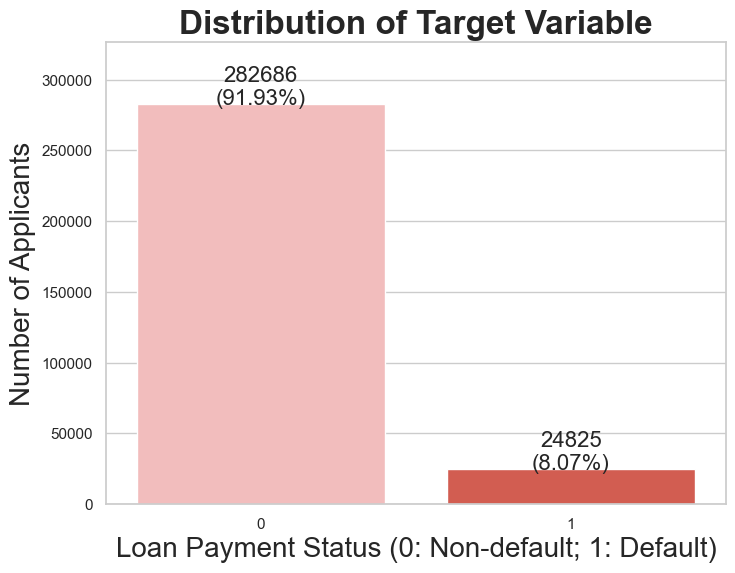

In [74]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))

ax = sns.countplot(x='TARGET', data=df_full, palette= ["#fbb4b4", '#e74c3c'])


plt.title('Distribution of Target Variable', fontsize=24, weight='bold')
plt.xlabel('Loan Payment Status (0: Non-default; 1: Default)', fontsize=20)
plt.ylabel('Number of Applicants', fontsize=20)

total = len(df_full)
for p in ax.patches:
    count = int(p.get_height())
    percent = f'{100 * count / total:.2f}%'
    label = f'{count}\n({percent})' 
    ax.annotate(label, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 12), textcoords = 'offset points',
                fontsize=16)

plt.ylim(0, ax.get_ylim()[1] * 1.1)

plt.show()


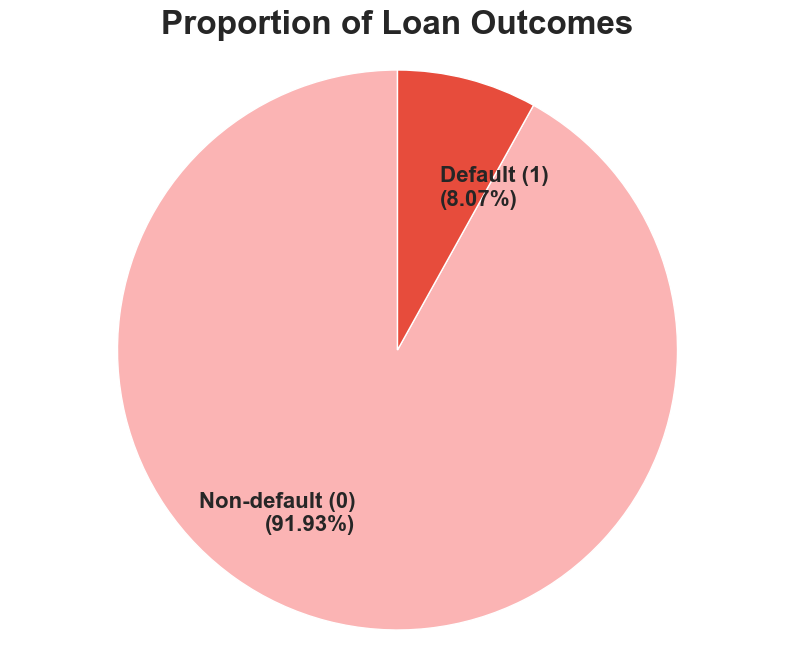

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set(style="whitegrid")

# --- 1. 准备数据 ---
target_counts = df_full['TARGET'].value_counts()
original_labels = ['Non-default (0)', 'Default (1)']
sizes = target_counts.values
total = sum(sizes)

# --- 2. 【核心修改】创建包含类别和百分比的新标签 ---
# 我们手动计算百分比，并和标签组合成新的字符串
new_labels = [f'{label}\n({size/total:.2%})' for label, size in zip(original_labels, sizes)]

# --- 3. 创建最终的饼状图 ---
plt.figure(figsize=(10, 8))

# 使用您喜欢的红色系
colors = ["#fbb4b4", '#e74c3c']

plt.pie(sizes, 
        # explode 参数已被移除
        labels=new_labels,      # <--- 使用我们创建的新标签
        colors=colors,
        autopct=None,           # <--- 关闭自动百分比显示
        shadow=False,           # <--- 关闭阴影
        startangle=90,
        textprops={'fontsize': 16, 'weight': 'bold'}, # 字体加粗更清晰
        labeldistance=0.6       # <--- 将标签拉到饼图内部 (小于1即可)
       )

# --- 4. 添加标题和确保图形为正圆形 ---
plt.title('Proportion of Loan Outcomes', fontsize=24, weight='bold')
plt.axis('equal')  # 确保饼状图是正圆形

plt.show()

### First View of Important Features

##### Total Income Distribution (Histgram)

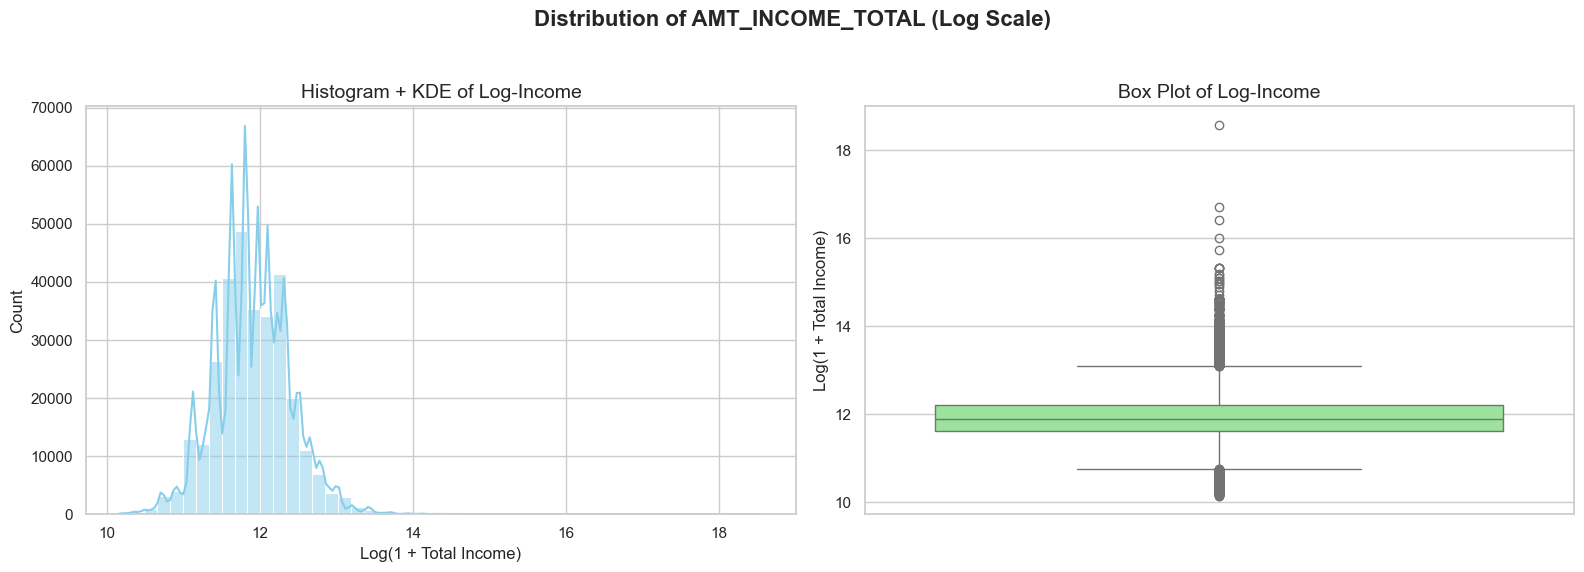

In [ ]:
# log(total income + 1)
df_full['LOG_INCOME'] = np.log1p(df_full['AMT_INCOME_TOTAL'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# histplot
sns.histplot(df_full['LOG_INCOME'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram + KDE of Log-Income', fontsize=14)
axes[0].set_xlabel('Log(1 + Total Income)', fontsize=12)

# boplot
sns.boxplot(y=df_full['LOG_INCOME'], ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot of Log-Income', fontsize=14)
axes[1].set_ylabel('Log(1 + Total Income)', fontsize=12)

fig.suptitle('Distribution of AMT_INCOME_TOTAL (Log Scale)', fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

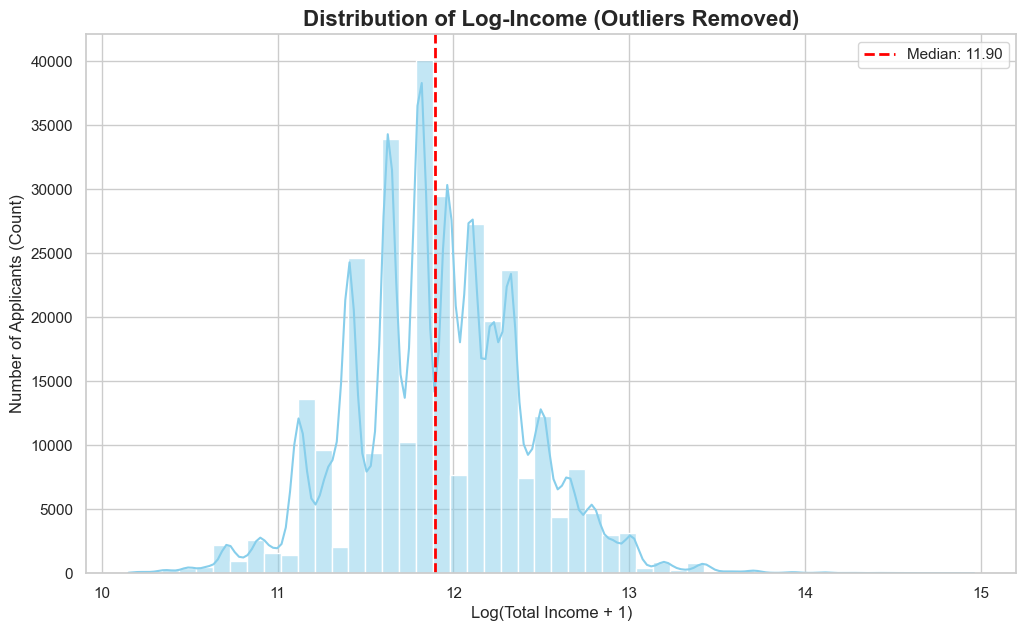

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

if 'LOG_INCOME' not in df_full.columns:
    df_full['LOG_INCOME'] = np.log1p(df_full['AMT_INCOME_TOTAL'])

log_income_filtered = df_full[df_full['LOG_INCOME'] <= 15]['LOG_INCOME']

plt.figure(figsize=(12, 7))

sns.histplot(log_income_filtered, bins=50, kde=True, color='skyblue')

median_val = log_income_filtered.median()
plt.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')

plt.title('Distribution of Log-Income (Outliers Removed)', fontsize=16, weight='bold')
plt.xlabel('Log(Total Income + 1)', fontsize=12)
plt.ylabel('Number of Applicants (Count)', fontsize=12)
plt.legend()

plt.show()

##### Credit Amount Distribution (Histgram)

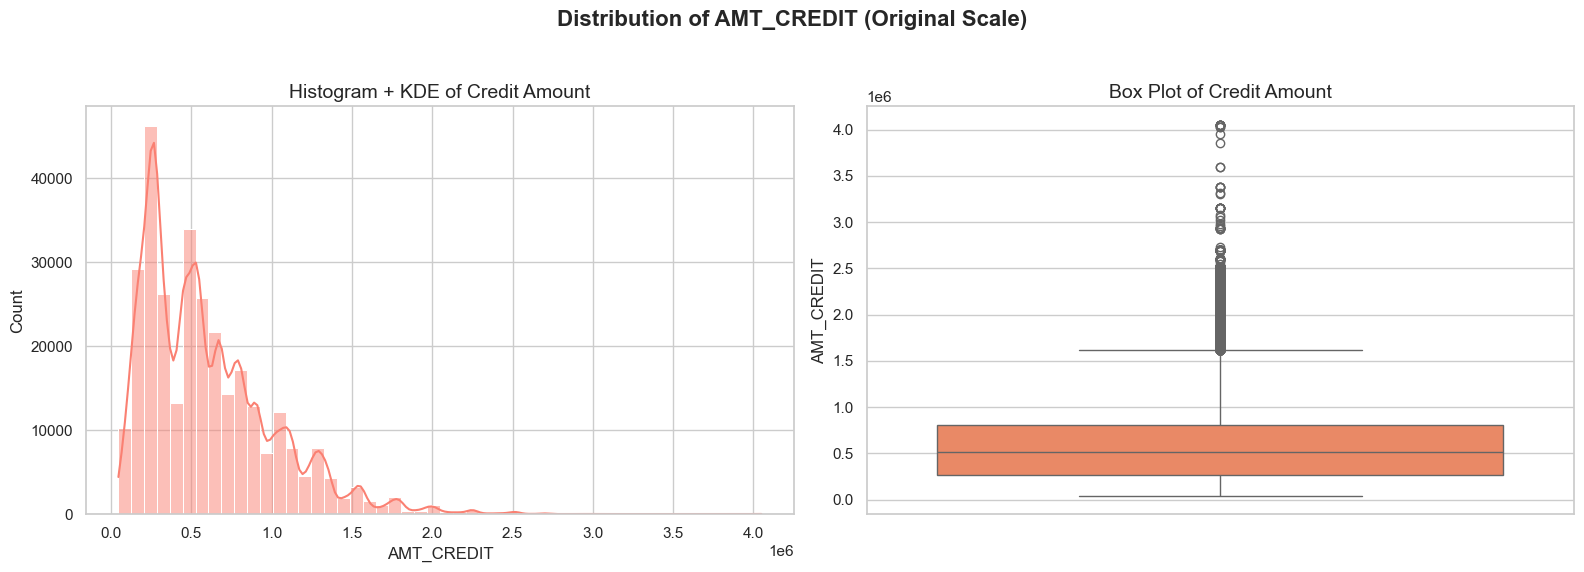

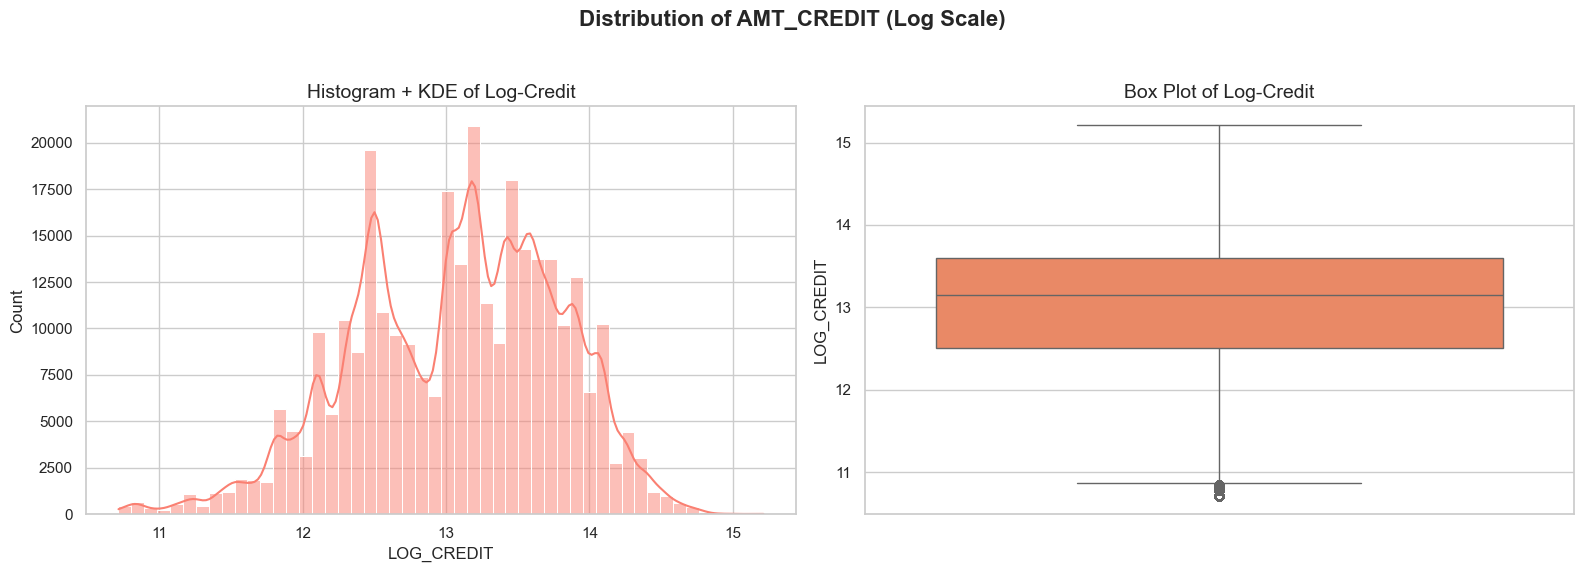

In [27]:
# Original Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df_full['AMT_CREDIT'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Histogram + KDE of Credit Amount', fontsize=14)
sns.boxplot(y=df_full['AMT_CREDIT'], ax=axes[1], color='coral')
axes[1].set_title('Box Plot of Credit Amount', fontsize=14)
fig.suptitle('Distribution of AMT_CREDIT (Original Scale)', fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Log Transform Distribution
df_full['LOG_CREDIT'] = np.log1p(df_full['AMT_CREDIT'])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df_full['LOG_CREDIT'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Histogram + KDE of Log-Credit', fontsize=14)
sns.boxplot(y=df_full['LOG_CREDIT'], ax=axes[1], color='coral')
axes[1].set_title('Box Plot of Log-Credit', fontsize=14)
fig.suptitle('Distribution of AMT_CREDIT (Log Scale)', fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##### Distribution between Income and Credit (Heatmap)

Original data points: 307511
Data points after filtering: 307496
Removed 15 outliers.


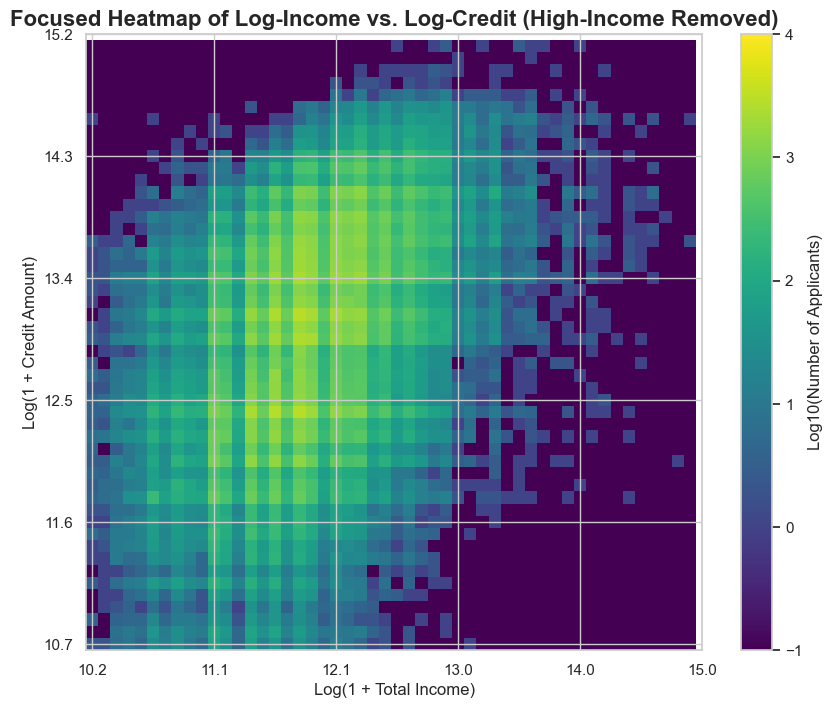

In [ ]:
if 'LOG_INCOME' not in df_full.columns:
    df_full['LOG_INCOME'] = np.log1p(df_full['AMT_INCOME_TOTAL'])
if 'LOG_CREDIT' not in df_full.columns:
    df_full['LOG_CREDIT'] = np.log1p(df_full['AMT_CREDIT'])

df_filtered = df_full[df_full['LOG_INCOME'] < 15].copy()
print(f"Original data points: {len(df_full)}")
print(f"Data points after filtering: {len(df_filtered)}")
print(f"Removed {len(df_full) - len(df_filtered)} outliers.")

nbins = 50

heatmap, xedges, yedges = np.histogram2d(
    df_filtered['LOG_INCOME'], df_filtered['LOG_CREDIT'], bins=nbins
)
heatmap[heatmap == 0] = 0.1

vmin_setting = -1
vmax_setting = 4

plt.figure(figsize=(10, 8))
plt.imshow(np.log10(heatmap).T, origin='lower', cmap='viridis', vmin=vmin_setting, vmax=vmax_setting)


plt.title('Focused Heatmap of Log-Income vs. Log-Credit (High-Income Removed)', fontsize=16, weight='bold')
plt.xlabel('Log(1 + Total Income)', fontsize=12)
plt.ylabel('Log(1 + Credit Amount)', fontsize=12)

# Set the tick labels
plt.xticks(np.arange(nbins + 1)[::10], np.round(xedges[::10], 1))
plt.yticks(np.arange(nbins + 1)[::10], np.round(yedges[::10], 1))

plt.colorbar(label='Log10(Number of Applicants)')
plt.show()


##### Previous Reject Counts (Bar Plot)

C:\Users\admin\AppData\Local\Temp\ipykernel_6680\3964156163.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


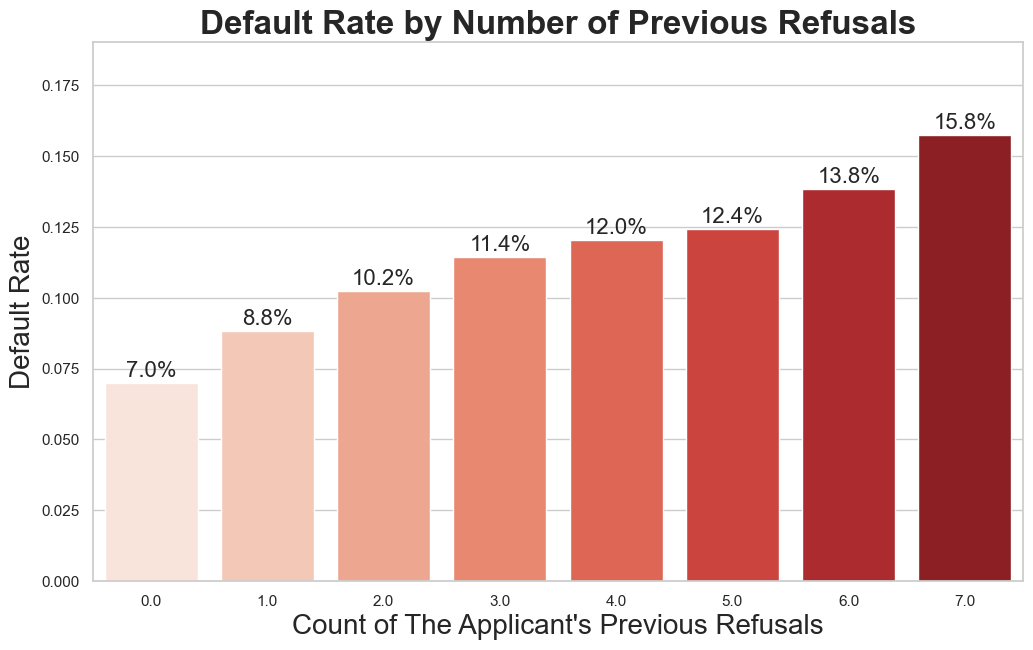

In [ ]:

# Focus on small amount of previous refusal 
refusal_counts = df_full[df_full['PREV_STATUS_REFUSED'] < 8].copy()
refusal_agg = refusal_counts.groupby('PREV_STATUS_REFUSED')['TARGET'].mean().reset_index()

# bar plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='PREV_STATUS_REFUSED',
    y='TARGET',
    data=refusal_agg,
    palette='Reds'
)

for p in ax.patches:
    ax.annotate(f'{p.get_height() * 100:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=16)

plt.title('Default Rate by Number of Previous Refusals', fontsize=24, weight='bold')
plt.xlabel("Count of The Applicant's Previous Refusals", fontsize=20)
plt.ylabel('Default Rate', fontsize=20)

plt.ylim(0, ax.get_ylim()[1] * 1.15)

plt.show()

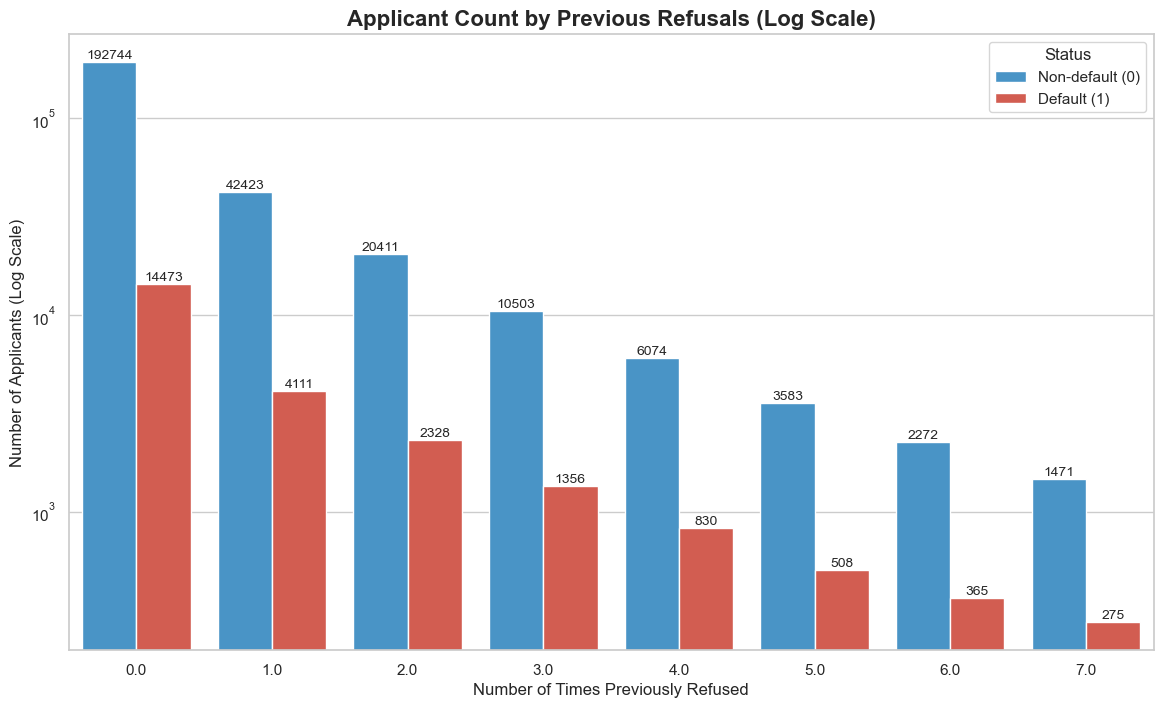

In [ ]:
df_plot = df_full[df_full['PREV_STATUS_REFUSED'] < 8].copy()


plt.figure(figsize=(14, 8))
ax = sns.countplot(
    x='PREV_STATUS_REFUSED',
    hue='TARGET',
    data=df_plot,
    palette=['#3498db', '#e74c3c']
)


ax.set_yscale('log')


for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10) 

plt.title('Applicant Count by Previous Refusals (Log Scale)', fontsize=16, weight='bold')
plt.xlabel('Number of Times Previously Refused', fontsize=12)
plt.ylabel('Number of Applicants (Log Scale)', fontsize=12)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Non-default (0)', 'Default (1)'], title='Status')

plt.show()


##### Distribution Between Income and Education (Violin Plot)

Original Data Points: 307511
After Removing Outliers: 307496


C:\Users\admin\AppData\Local\Temp\ipykernel_6680\1737994845.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


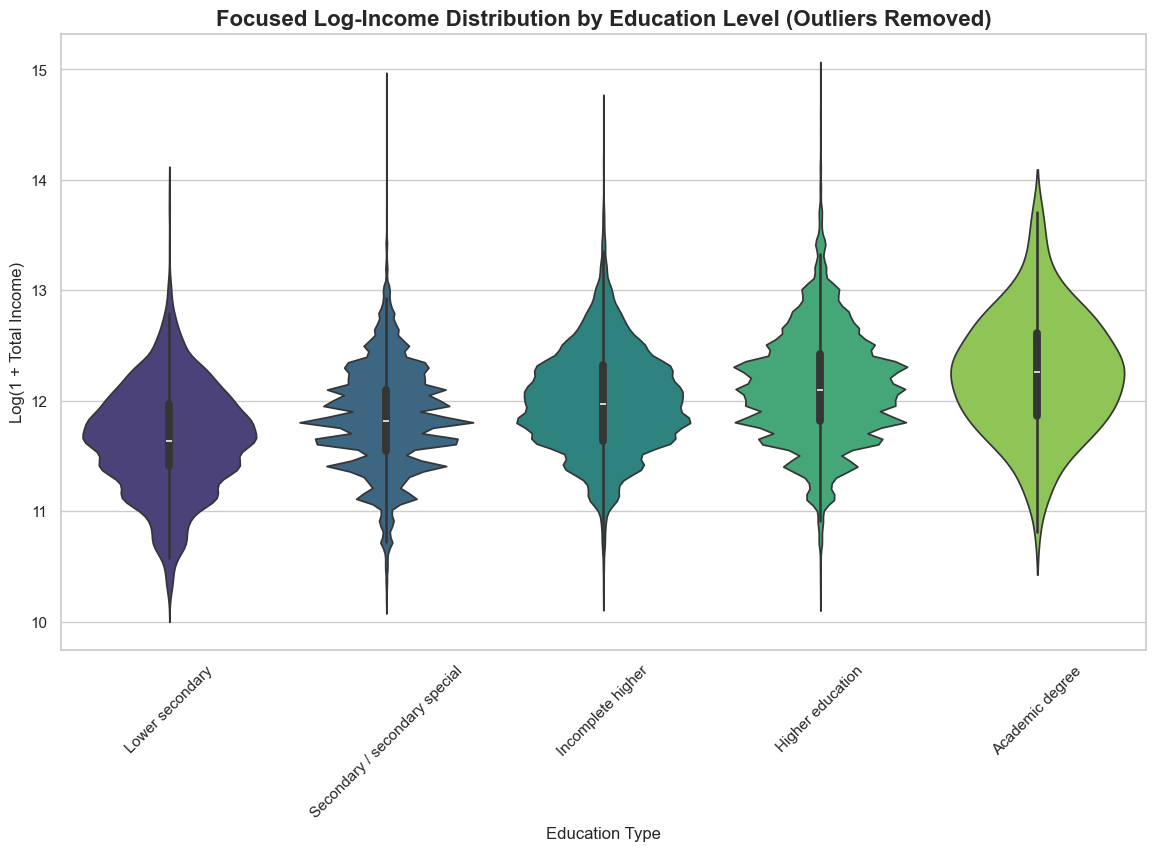

In [48]:
df_plot_filtered = df_full[df_full['LOG_INCOME'] <= 15].copy()
print(f"Original Data Points: {len(df_full)}")
print(f"After Removing Outliers: {len(df_plot_filtered)}")


education_order = [
    'Lower secondary', 'Secondary / secondary special',
    'Incomplete higher', 'Higher education', 'Academic degree'
]

plt.figure(figsize=(14, 8))


sns.violinplot(
    x='NAME_EDUCATION_TYPE',
    y='LOG_INCOME',
    data=df_plot_filtered,
    order=education_order,
    palette='viridis'
)

plt.title('Focused Log-Income Distribution by Education Level (Outliers Removed)', fontsize=16, weight='bold')
plt.xlabel('Education Type', fontsize=12)
plt.ylabel('Log(Total Income + 1)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

##### Distribution Between External Credit Score and Education (Box Plot)

C:\Users\admin\AppData\Local\Temp\ipykernel_6680\2100245282.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


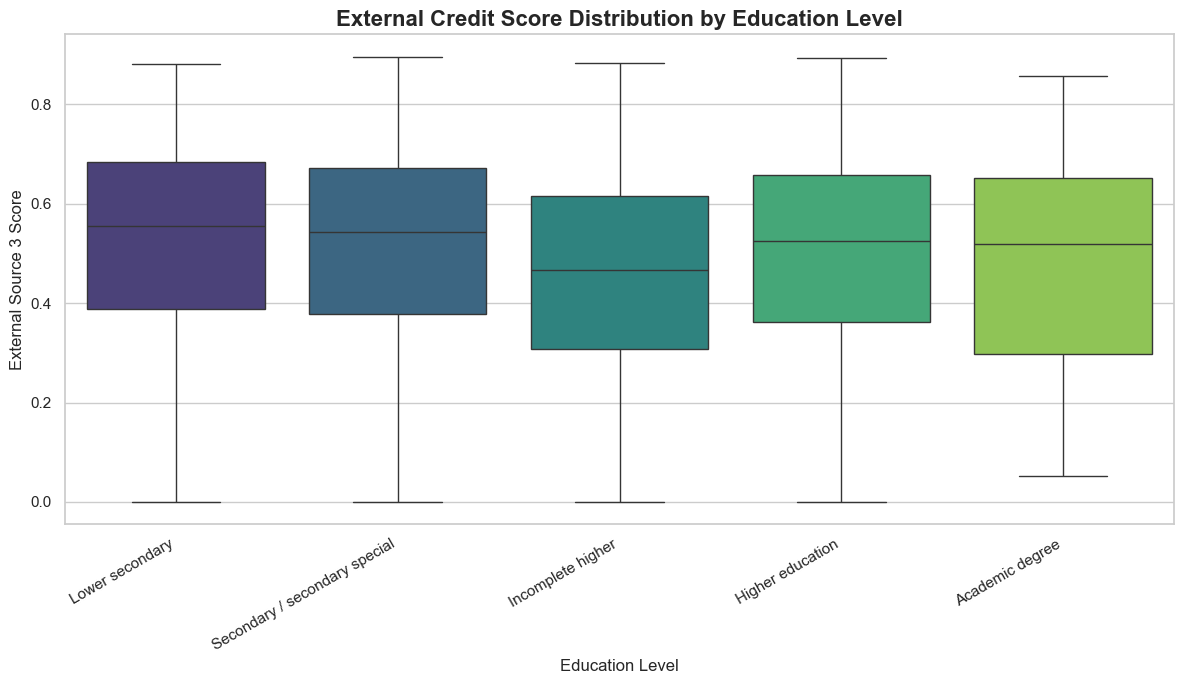

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

education_order = [
    'Lower secondary', 'Secondary / secondary special', 
    'Incomplete higher', 'Higher education', 'Academic degree'
]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_full, 
    x='NAME_EDUCATION_TYPE', 
    y='EXT_SOURCE_3', 
    order=education_order,
    palette='viridis'
)

plt.title('External Credit Score Distribution by Education Level', fontsize=16, weight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('External Source 3 Score', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

##### Distribution between Goods Price and Credit Amount (Heatmap)

Original data points: 307511
Data points after dropping NaNs for heatmap: 307233


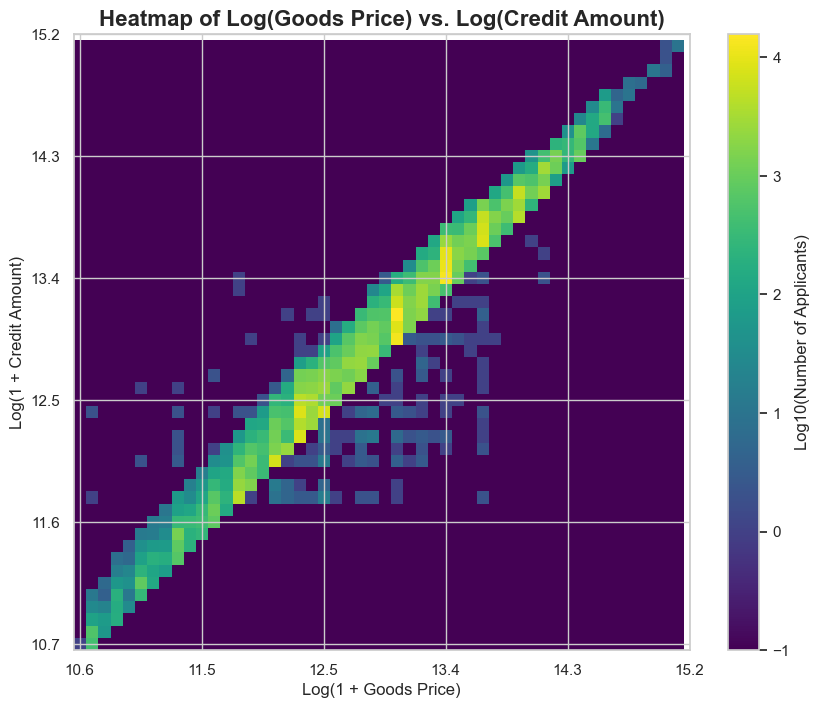

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# df_full = pd.read_csv('../data/application_merged_data.csv')

if 'LOG_GOODS_PRICE' not in df_full.columns:
    df_full['LOG_GOODS_PRICE'] = np.log1p(df_full['AMT_GOODS_PRICE'])
if 'LOG_CREDIT' not in df_full.columns:
    df_full['LOG_CREDIT'] = np.log1p(df_full['AMT_CREDIT'])

df_heatmap = df_full[['LOG_GOODS_PRICE', 'LOG_CREDIT']].dropna()

print(f"Original data points: {len(df_full)}")
print(f"Data points after dropping NaNs for heatmap: {len(df_heatmap)}")


nbins = 50
heatmap, xedges, yedges = np.histogram2d(
    df_heatmap['LOG_GOODS_PRICE'], 
    df_heatmap['LOG_CREDIT'], 
    bins=nbins
)
heatmap[heatmap == 0] = 0.1 


plt.figure(figsize=(10, 8))
plt.imshow(
    np.log10(heatmap).T, 
    origin='lower', 
    cmap='viridis'
)

plt.title('Heatmap of Log(Goods Price) vs. Log(Credit Amount)', fontsize=16, weight='bold')
plt.xlabel('Log(1 + Goods Price)', fontsize=12)
plt.ylabel('Log(1 + Credit Amount)', fontsize=12)

plt.xticks(np.arange(nbins + 1)[::10], np.round(xedges[::10], 1))
plt.yticks(np.arange(nbins + 1)[::10], np.round(yedges[::10], 1))

plt.colorbar(label='Log10(Number of Applicants)')
plt.show()

##### Distribution Between Income and Income Type (Violin Plot)

C:\Users\admin\AppData\Local\Temp\ipykernel_6680\1037528070.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


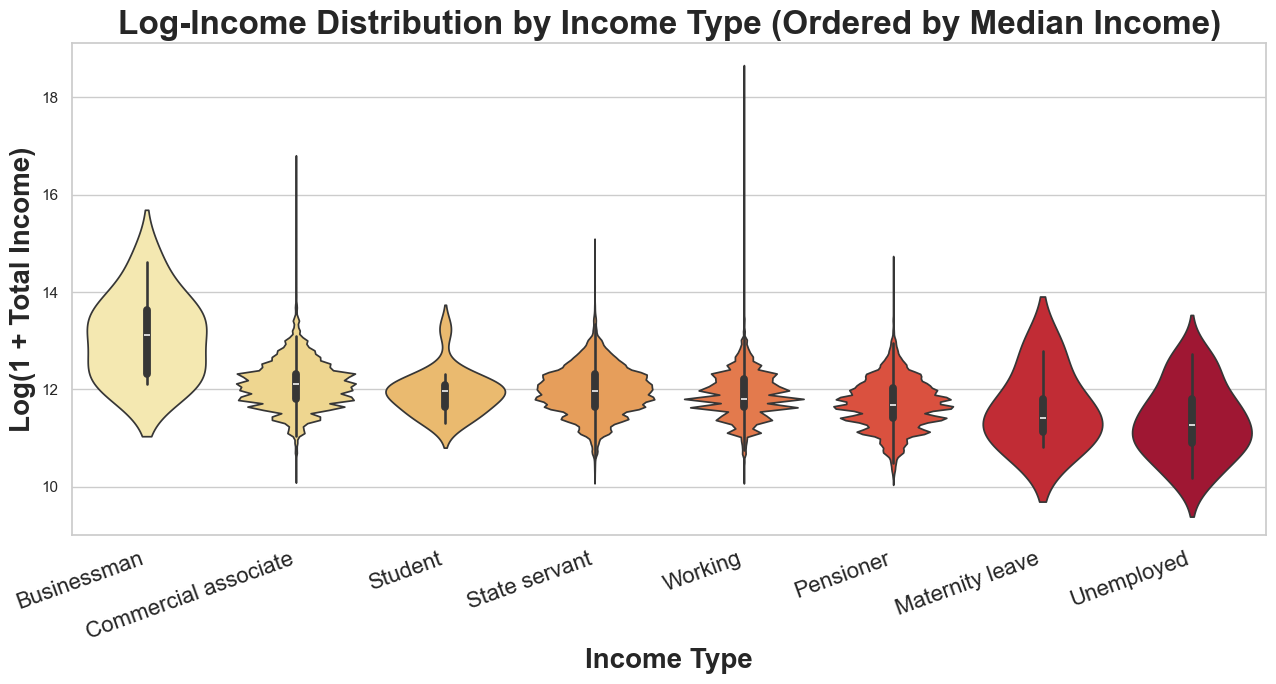

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if 'LOG_INCOME' not in df_full.columns:
    df_full['LOG_INCOME'] = np.log1p(df_full['AMT_INCOME_TOTAL'])

median_income_by_type = df_full.groupby('NAME_INCOME_TYPE')['LOG_INCOME'].median().sort_values(ascending=False)
ordered_income_types = median_income_by_type.index.tolist()


plt.figure(figsize=(13, 7))

sns.violinplot(
    data=df_full,
    x='NAME_INCOME_TYPE',
    y='LOG_INCOME',
    palette='YlOrRd',
    order=ordered_income_types
)

min_log_income = df_full['LOG_INCOME'].min()
plt.ylim(bottom=9) 

plt.title('Log-Income Distribution by Income Type (Ordered by Median Income)', fontsize=24, weight='bold')
plt.xlabel('Income Type', fontsize=20, weight='bold')
plt.ylabel('Log(1 + Total Income)', fontsize=20, weight='bold')
plt.xticks(rotation=20, ha='right', fontsize=16)
plt.tight_layout()
plt.show()

##### Distribution Between Income and Living City Rating (Violin Plot)

C:\Users\admin\AppData\Local\Temp\ipykernel_37420\3815566205.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


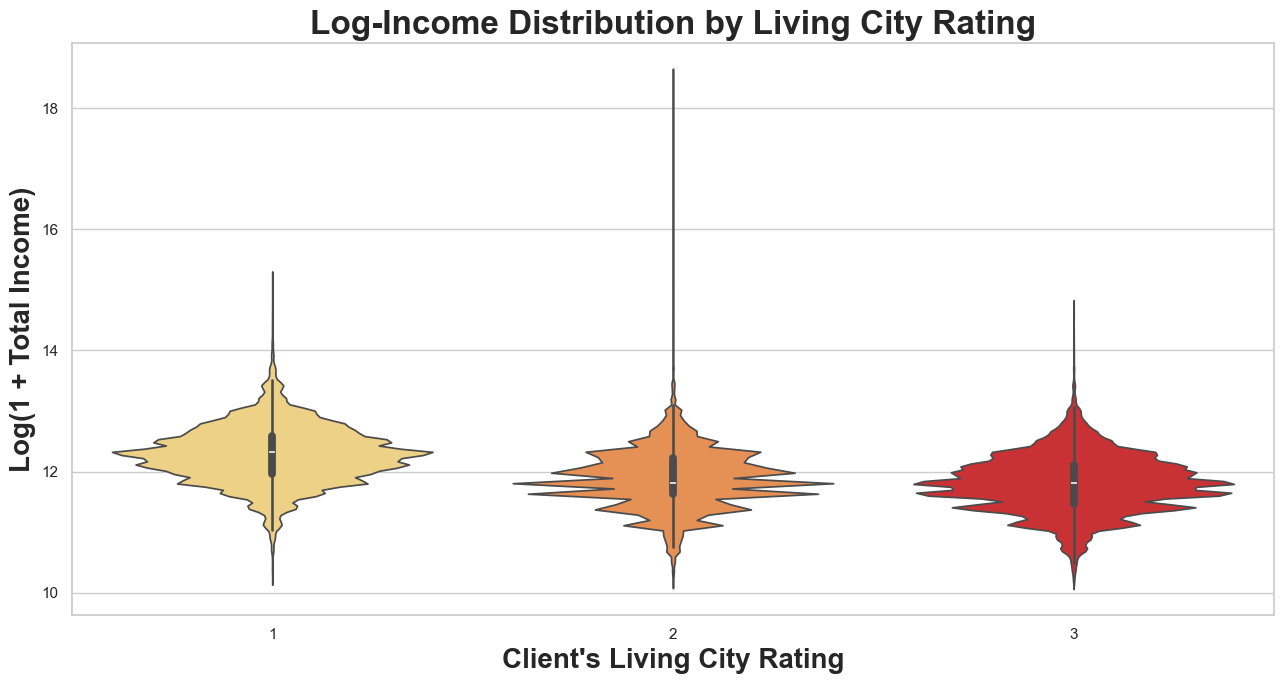

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if 'LOG_INCOME' not in df_full.columns:
    df_full['LOG_INCOME'] = np.log1p(df_full['AMT_INCOME_TOTAL'])
    
# ### Filter (Removed Outliers)
# df_filtered = df_full[df_full['LOG_INCOME'] < 15].copy()
if 'LOG_GOODS_PRICE' not in df_full.columns:
    df_full['LOG_GOODS_PRICE'] = np.log1p(df_full['AMT_GOODS_PRICE'])

if 'LOG_CREDIT' not in df_full.columns:
    df_full['LOG_CREDIT'] = np.log1p(df_full['AMT_CREDIT'])

plt.figure(figsize=(13, 7))

sns.violinplot(
    # data=df_filtered,
    data=df_full,
    x='REGION_RATING_CLIENT_W_CITY',
    y='LOG_INCOME',
    palette='YlOrRd',
    # order=ordered_income_types
)

# min_log_income = df_full['LOG_CREDIT'].min()
# plt.ylim(bottom=9) 

plt.title('Log-Income Distribution by Living City Rating', fontsize=24, weight='bold')
plt.xlabel("Client's Living City Rating", fontsize=20, weight='bold')
plt.ylabel('Log(1 + Total Income)', fontsize=20, weight='bold')
# plt.xticks(rotation=20, ha='right', fontsize=16)
plt.tight_layout()
plt.show()